In [ ]:
# from collections import defaultdict
# import json
# import math

# # Load data
# with open('step_stats_5.json') as f:
#     data = json.load(f)
# with open('randla_stats_5.json') as f2:
#     data2 = json.load(f2)

# with open('combine_stats_5.json') as f3:
#     data3 = json.load(f3)
# with open('step_stats_6.json') as f4:
#     data4 = json.load(f4)
# with open('randla_stats_6.json') as f5:
#     data5 = json.load(f5)
# with open('combine_stats_6.json') as f6:
#     data6 = json.load(f6)
    
# def euclidean(p1, p2):
#     """Simple 2D Euclidean distance"""
#     return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# def process_data(data):
#     groups = defaultdict(list)
#     for entry in data:
#         start = tuple(round(x) for x in entry["start_point"])
#         goal = tuple(round(x) for x in entry["goal_point"])
#         key = (start, goal)
#         groups[key].append(entry)

#     stats = {}
#     for key, group in groups.items():
#         total_lengths = [sum(entry["total_length"]) for entry in group]
#         dist_togoals = [entry["dist_to_goal"] for entry in group]
#         collision_counts = [entry["collision_count"] for entry in group]
#         counts = [entry["count"] for entry in group]
#         reach_goals = [entry["reach_goal"] for entry in group]

#         # New: distances involving current_pos
#         dist_start_curr = [euclidean(entry["start_point"], entry["current_pos"]) for entry in group]
#         dist_curr_goal = [euclidean(entry["current_pos"], entry["goal_point"]) for entry in group]
#         success_collision_counts = [entry["collision_count"] for entry in group if entry.get("reach_goal")]
#         mean_collision_success = (sum(success_collision_counts) / len(success_collision_counts)
#                                   if success_collision_counts else 0.0)
#         mean_total_length = sum(total_lengths) / len(total_lengths)
#         mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
#         mean_collision = sum(collision_counts) / len(collision_counts)
#         mean_count = sum(counts) / len(counts)
#         reach_goal_rate = sum(reach_goals) / len(reach_goals)

#         mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
#         mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

#         stats[key] = {
#             "total_length": mean_total_length,
#             "dist_togoal": mean_dist_togoal,
#             "collision_count": mean_collision,
#             "count": mean_count,
#             "reach_goal_rate": reach_goal_rate * 100,  # percent
#             "dist_start_to_current": mean_start_curr,
#             "dist_current_to_goal": mean_curr_goal,
#             "mean_collision_success": mean_collision_success
#         }
#     return stats

# # Process both datasets
# stats1 = process_data(data)
# stats2 = process_data(data2)
# stats3 = process_data(data3)
# stats4 = process_data(data4)
# stats5 = process_data(data5)
# stats6 = process_data(data6)



In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- assume env_map and relabel_stats() are defined as in your snippet ---
# env_map = {
#     ((-30, 7), (-22, 17)): "normal",
#     ((-30, -20), (-22, -6)): "uneven",
#     ((-31, -44), (-20, -37)): "ramp",
#     ((-55, 5), (-41, 5)): "two_height_ramp",
#     ((-33, 40), (-20, 40)): "ramp_obstacle",
#     ((-55, -13), (-41, -13)): "hole",
# }

# def relabel_stats(stats):
#     new_stats = {}
#     for (start, goal), values in stats.items():
#         label = env_map.get((start, goal), f"{start}→{goal}")
#         new_stats[label] = values
#     return new_stats

# # Label stats
# stats1_labeled = relabel_stats(stats1)  # step 5
# stats2_labeled = relabel_stats(stats2)  # randla 5
# stats3_labeled = relabel_stats(stats3)  # combine 5
# stats4_labeled = relabel_stats(stats4)  # step 6
# stats5_labeled = relabel_stats(stats5)  # randla 6
# stats6_labeled = relabel_stats(stats6)  # combine 6

# # Collect labels
# all_labels = sorted(
#     set(stats1_labeled) | set(stats2_labeled) | set(stats3_labeled) |
#     set(stats4_labeled) | set(stats5_labeled) | set(stats6_labeled)
# )

# def rgr(d, label): 
#     return d.get(label, {}).get("reach_goal_rate", 0)

# # Data arrays
# step_5   = [rgr(stats1_labeled, label) for label in all_labels]
# step_6   = [rgr(stats4_labeled, label) for label in all_labels]
# randla_5 = [rgr(stats2_labeled, label) for label in all_labels]
# randla_6 = [rgr(stats5_labeled, label) for label in all_labels]
# combine_5= [rgr(stats3_labeled, label) for label in all_labels]
# combine_6= [rgr(stats6_labeled, label) for label in all_labels]

# # --- Layout ---
# group_spacing = 2.5
# x = np.arange(len(all_labels)) * group_spacing
# width = 0.25
# offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# plt.figure(figsize=(max(14, len(all_labels)*0.8), 6))

# # --- Set 5 (Hatched) ---
# plt.bar(x + offsets[0], step_5,   width, color='tomato',    alpha=0.75, label='Step (60%)',   hatch='xx', edgecolor='black')
# plt.bar(x + offsets[2], randla_5, width, color='steelblue', alpha=0.75, label='RandLA (60%)', hatch='xx', edgecolor='black')
# plt.bar(x + offsets[4], combine_5,width, color='green',     alpha=0.75, label='Combine (60%)',hatch='xx', edgecolor='black')

# # --- Set 6 (Solid) ---
# plt.bar(x + offsets[1], step_6,   width, color='tomato',    alpha=0.95, label='Step (80%)')
# plt.bar(x + offsets[3], randla_6, width, color='steelblue', alpha=0.95, label='RandLA (80%)')
# plt.bar(x + offsets[5], combine_6,width, color='green',     alpha=0.95, label='Combine (80%)')

# # --- Styling ---
# plt.xticks(x, all_labels, rotation=45, ha='right')
# plt.ylabel("Success Rate (%)")
# plt.ylim(0, 110)
# plt.title("Success Rate per Environment — 60% risk vs 80% risk on a star")
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)
# plt.legend(ncol=3, frameon=True)
# plt.tight_layout()
# plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- mapping + relabel (same as before) ---
# env_map = {
#     ((-30, 7), (-22, 17)): "normal",
#     ((-30, -20), (-22, -6)): "uneven",
#     ((-31, -44), (-20, -37)): "ramp",
#     ((-55, 5), (-41, 5)): "two_height_ramp",
#     ((-33, 40), (-20, 40)): "ramp_obstacle",
#     ((-55, -13), (-41, -13)): "hole",
# }

# def relabel_stats(stats):
#     out = {}
#     for (start, goal), vals in stats.items():
#         out[env_map.get((start, goal), f"{start}→{goal}")] = vals
#         # expecting keys like {"collision_count": ..., ...}
#     return out

# # Label stats for both sets
# stats1_labeled = relabel_stats(stats1)  # step 5
# stats2_labeled = relabel_stats(stats2)  # randla 5
# stats3_labeled = relabel_stats(stats3)  # combine 5
# stats4_labeled = relabel_stats(stats4)  # step 6
# stats5_labeled = relabel_stats(stats5)  # randla 6
# stats6_labeled = relabel_stats(stats6)  # combine 6

# # All environment labels
# all_labels = sorted(
#     set(stats1_labeled) | set(stats2_labeled) | set(stats3_labeled) |
#     set(stats4_labeled) | set(stats5_labeled) | set(stats6_labeled)
# )

# def get_collision(d, label):
#     return d.get(label, {}).get("collision_count", 0)

# # Collision means per env
# step5   = [get_collision(stats1_labeled, label) for label in all_labels]
# step6   = [get_collision(stats4_labeled, label) for label in all_labels]
# randla5 = [get_collision(stats2_labeled, label) for label in all_labels]
# randla6 = [get_collision(stats5_labeled, label) for label in all_labels]
# comb5   = [get_collision(stats3_labeled, label) for label in all_labels]
# comb6   = [get_collision(stats6_labeled, label) for label in all_labels]

# # --- layout: 6 bars per environment in the requested order ---
# group_spacing = 2.5
# x = np.arange(len(all_labels)) * group_spacing
# width = 0.25
# offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width  # S5,S6,R5,R6,C5,C6

# plt.figure(figsize=(max(14, len(all_labels)*0.8), 6))

# # Set 5 (hatched + black edge)
# plt.bar(x + offsets[0], step5,   width, color='tomato',    alpha=0.75, label='Step (60%)',   hatch='xx', edgecolor='black')
# plt.bar(x + offsets[2], randla5, width, color='steelblue', alpha=0.75, label='RandLA (60%)', hatch='xx', edgecolor='black')
# plt.bar(x + offsets[4], comb5,width, color='green',     alpha=0.75, label='Combine (60%)',hatch='xx', edgecolor='black')

# # --- Set 6 (Solid) ---
# plt.bar(x + offsets[1], step6,   width, color='tomato',    alpha=0.95, label='Step (80%)')
# plt.bar(x + offsets[3], randla6, width, color='steelblue', alpha=0.95, label='RandLA (80%)')
# plt.bar(x + offsets[5], comb6,   width, color='green',     alpha=0.95, label='Combine (80%)')

# # Y-limit with headroom
# ymax = max(step5 + step6 + randla5 + randla6 + comb5 + comb6) if all_labels else 1
# # plt.ylim(0, ymax * 1.15)
# plt.ylim(0, ymax * 1.15)

# # Cosmetics
# plt.xticks(x, all_labels, rotation=45, ha='right')
# plt.ylabel("Mean Collision Count")
# plt.title("Success Rate per Environment — 60% risk vs 80% risk on a star")
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)
# plt.legend(ncol=3, frameon=True)
# plt.tight_layout()
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- mapping + relabel (same as before) ---
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    out = {}
    for (start, goal), vals in stats.items():
        out[env_map.get((start, goal), f"{start}→{goal}")] = vals
        # expecting keys like {"collision_count": ..., ...}
    return out

# Label stats for both sets
stats1_labeled = relabel_stats(stats1)  # step 5
stats2_labeled = relabel_stats(stats2)  # randla 5
stats3_labeled = relabel_stats(stats3)  # combine 5
stats4_labeled = relabel_stats(stats4)  # step 6
stats5_labeled = relabel_stats(stats5)  # randla 6
stats6_labeled = relabel_stats(stats6)  # combine 6

# All environment labels
all_labels = sorted(
    set(stats1_labeled) | set(stats2_labeled) | set(stats3_labeled) |
    set(stats4_labeled) | set(stats5_labeled) | set(stats6_labeled)
)

def get_collision(d, label):
    return d.get(label, {}).get("mean_collision_success", 0)

# Collision means per env
step5   = [get_collision(stats1_labeled, label) for label in all_labels]
step6   = [get_collision(stats4_labeled, label) for label in all_labels]
randla5 = [get_collision(stats2_labeled, label) for label in all_labels]
randla6 = [get_collision(stats5_labeled, label) for label in all_labels]
comb5   = [get_collision(stats3_labeled, label) for label in all_labels]
comb6   = [get_collision(stats6_labeled, label) for label in all_labels]

# --- layout: 6 bars per environment in the requested order ---
group_spacing = 2.5
x = np.arange(len(all_labels)) * group_spacing
width = 0.25
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width  # S5,S6,R5,R6,C5,C6

plt.figure(figsize=(max(14, len(all_labels)*0.8), 6))

# Set 5 (hatched + black edge)
plt.bar(x + offsets[0], step5,   width, color='tomato',    alpha=0.75, label='Step (60%)',   hatch='xx', edgecolor='black')
plt.bar(x + offsets[2], randla5, width, color='steelblue', alpha=0.75, label='RandLA (60%)', hatch='xx', edgecolor='black')
plt.bar(x + offsets[4], comb5,width, color='green',     alpha=0.75, label='Combine (60%)',hatch='xx', edgecolor='black')

# --- Set 6 (Solid) ---
plt.bar(x + offsets[1], step6,   width, color='tomato',    alpha=0.95, label='Step (80%)')
plt.bar(x + offsets[3], randla6, width, color='steelblue', alpha=0.95, label='RandLA (80%)')
plt.bar(x + offsets[5], comb6,   width, color='green',     alpha=0.95, label='Combine (80%)')

# Y-limit with headroom
ymax = max(step5 + step6 + randla5 + randla6 + comb5 + comb6) if all_labels else 1
# plt.ylim(0, ymax * 1.15)
plt.ylim(0, ymax * 1.15)

# Cosmetics
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Collision Count per Success Rate Environment — 60% risk vs 80% risk on a star")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(ncol=3, frameon=True)
plt.tight_layout()
plt.show()


NameError: name 'stats1' is not defined

# using less

In [7]:
from collections import defaultdict
import json
import math

# Load data
with open('step_stats_6.json') as f:
    data = json.load(f)
with open('randla_stats_6.json') as f2:
    data2 = json.load(f2)

with open('combine_stats_6.json') as f3:
    data3 = json.load(f3)

with open('random_4.json') as f4:
    data4 = json.load(f4)

with open('test_stats_10.json') as f5:
    data5 = json.load(f5)
def euclidean(p1, p2):
    """Simple 2D Euclidean distance"""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def process_data(data):
    groups = defaultdict(list)
    for entry in data:
        start = tuple(round(x) for x in entry["start_point"])
        goal = tuple(round(x) for x in entry["goal_point"])
        key = (start, goal)
        groups[key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # New: distances involving current_pos
        dist_start_curr = [euclidean(entry["start_point"], entry["current_pos"]) for entry in group]
        dist_curr_goal = [euclidean(entry["current_pos"], entry["goal_point"]) for entry in group]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)

        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        success_collision_counts = [entry["collision_count"] for entry in group if entry.get("reach_goal")]
        mean_collision_success = (sum(success_collision_counts) / len(success_collision_counts)
                                  if success_collision_counts else 0.0)
        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  # percent
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal,
            "mean_collision_success": mean_collision_success
        }
    return stats

# Process both datasets
stats1 = process_data(data)
stats2 = process_data(data2)
stats3 = process_data(data3)
stats4 = process_data(data4)
stats5 = process_data(data5)
# # Example printout for dataset 2
# for key, values in stats2.items():
#     print(f"Group {key}:")
#     for stat_name, stat_value in values.items():
#         if stat_name == "reach_goal_rate":
#             print(f"  {stat_name}: {stat_value:.2f}%")
#         else:
#             print(f"  {stat_name}: {stat_value:.4f}")
#     print()


6


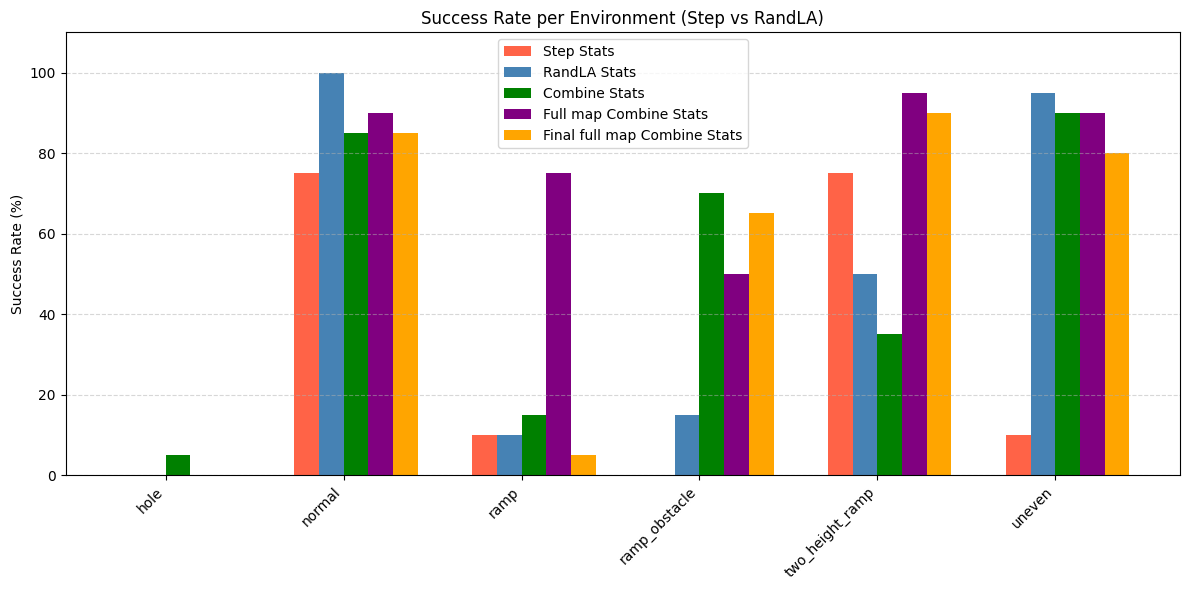

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Environment mapping (same as before)
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Convert stats1/stats2 keys from coordinates to labels
def relabel_stats(stats):
    new_stats = {}
    for (start, goal), values in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        new_stats[label] = values
    return new_stats

stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)
stats5_labeled = relabel_stats(stats5)
# Combine all labels
all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()).union(stats3_labeled.keys()).union(stats4_labeled.keys()))

step_rates = [stats1_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
randla_rates = [stats2_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
combine_rates = [stats3_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
full_rates = [stats4_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
test_rates = [stats5_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
print(len(full_rates))
# Increase spacing between environments
group_spacing = 1.8  # <-- wider gap between groups
x = np.arange(len(all_labels)) * group_spacing

# Make bars more centered relative to each group
width = 0.25  # narrower bars for cleaner grouping
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width, 2.5*width]
plt.figure(figsize=(max(12, len(all_labels)*0.7), 6))

plt.bar(x + offsets[0], step_rates, width, label='Step Stats', color='tomato')
plt.bar(x + offsets[1], randla_rates, width, label='RandLA Stats', color='steelblue')
plt.bar(x + offsets[2], combine_rates, width, label='Combine Stats', color='green')
plt.bar(x + offsets[3], full_rates, width, label='Full map Combine Stats', color='purple')
plt.bar(x + offsets[4], test_rates, width, label='Final full map Combine Stats', color='orange')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Success Rate (%)")
plt.ylim(0, 110)
plt.title("Success Rate per Environment (Step vs RandLA)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [9]:
# import matplotlib.pyplot as plt
# import numpy as np

# # --- Reuse relabelled stats ---
# stats1_labeled = relabel_stats(stats1)
# stats2_labeled = relabel_stats(stats2)
# stats3_labeled = relabel_stats(stats3)
# all_labels = sorted(set(stats1_labeled.keys()).union(stats2_labeled.keys()))

# # Extract values
# step_start_curr    = [stats1_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# randla_start_curr  = [stats2_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]
# combine_start_curr = [stats3_labeled.get(lbl, {}).get("dist_start_to_current", 0) for lbl in all_labels]

# step_curr_goal     = [stats1_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# randla_curr_goal   = [stats2_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]
# combine_curr_goal  = [stats3_labeled.get(lbl, {}).get("dist_current_to_goal", 0) for lbl in all_labels]

# # Centers for each group (add spacing between groups)
# x = np.arange(len(all_labels)) * 1.6

# # Bar geometry: 6 bars per group, symmetric offsets around center
# width = 0.18
# offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# plt.figure(figsize=(max(14, len(all_labels)*0.9), 6))

# # Step (solid + hatched)
# plt.bar(x + offsets[0], step_start_curr, width, label='Step: Start→Current', color='tomato')
# plt.bar(x + offsets[1], step_curr_goal,  width, label='Step: Current→Goal', color='tomato',
#         hatch='//', edgecolor='black')

# # RandLA (solid + hatched)
# plt.bar(x + offsets[2], randla_start_curr, width, label='RandLA: Start→Current', color='steelblue')
# plt.bar(x + offsets[3], randla_curr_goal,  width, label='RandLA: Current→Goal', color='steelblue',
#         hatch='\\\\', edgecolor='black')

# # Combine (solid + hatched)
# plt.bar(x + offsets[4], combine_start_curr, width, label='Combine: Start→Current', color='green')
# plt.bar(x + offsets[5], combine_curr_goal,  width, label='Combine: Current→Goal', color='green',
#         hatch='xx', edgecolor='black')

# plt.xticks(x, all_labels, rotation=45, ha='right')
# plt.ylabel("Mean Distance")
# plt.title("Mean Distances per Environment (Step vs RandLA)")
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# # Keep legend compact
# plt.legend(ncol=3, frameon=True)
# plt.tight_layout()
# plt.show()


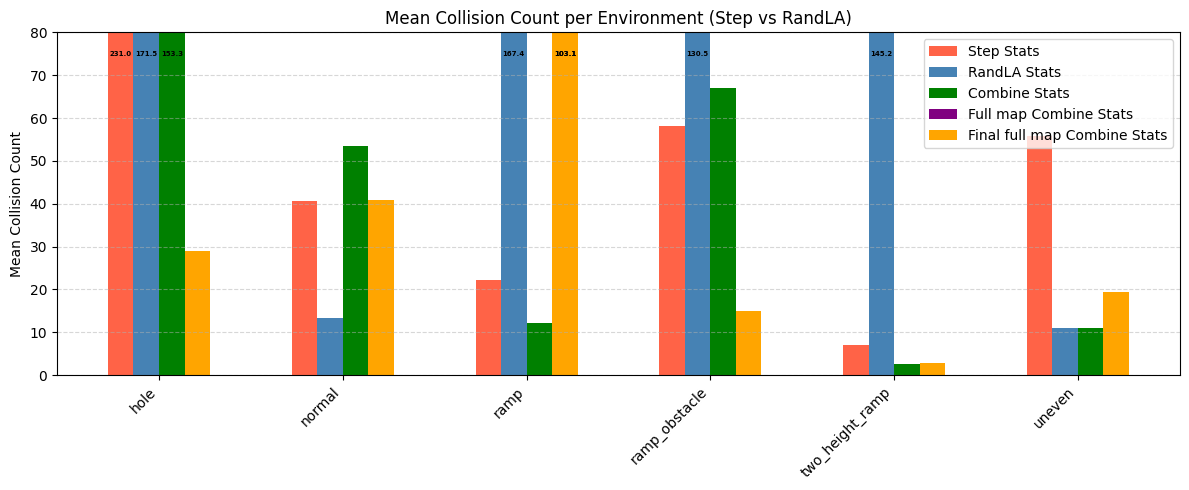

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Map from (rounded_start, rounded_goal) -> label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    """Convert {(start, goal): metrics} -> {label: metrics} using env_map.
       Falls back to 'start→goal' string if a pair isn't in env_map."""
    out = {}
    for (start, goal), vals in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        out[label] = vals
    return out

stats1_labeled = relabel_stats(stats1)  # step
stats2_labeled = relabel_stats(stats2)  # randla
stats3_labeled = relabel_stats(stats3)  # combine
stats4_labeled = relabel_stats(stats4)  # full map combine (or step6 in your earlier naming)
stats5_labeled = relabel_stats(stats5)

# Use ALL labels across the 4 series (not just step+randla)
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled)
)

# Build arrays
step_collision_means    = [stats1_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]  
randla_collision_means  = [stats2_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
combine_collision_means = [stats3_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
full_collision_means    = [stats4_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]
another_collision_means = [stats5_labeled.get(label, {}).get("collision_count", 0) for label in all_labels]

# --- Looser spacing + centered offsets (like your success-rate plot) ---
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.25
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]  # Step, RandLA, Combine, Full

plt.figure(figsize=(max(12, len(all_labels)*0.7), 5))

bars1 = plt.bar(x + offsets[0], step_collision_means,    width, label='Step Stats',                color='tomato')
bars2 = plt.bar(x + offsets[1], randla_collision_means,  width, label='RandLA Stats',              color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_collision_means, width, label='Combine Stats',             color='green')
bars4 = plt.bar(x + offsets[3], full_collision_means,    width, label='Full map Combine Stats',    color='purple')
bars5 = plt.bar(x + offsets[3], full_collision_means,    width, label='Final full map Combine Stats',    color='orange')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Collision Count per Environment (Step vs RandLA)")
plt.legend()

ylim_val = 80
plt.ylim(0, ylim_val)  # Fixed y-limit

plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

def label_only_over_limit(bars, limit=ylim_val, label_y=75):
    for bar in bars:
        height = bar.get_height()
        if height > limit:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{height:.1f}',
                ha='center',
                va='center',
                fontsize=5,
                fontweight='bold',
                color='black'
            )

label_only_over_limit(bars1)
label_only_over_limit(bars2)
label_only_over_limit(bars3)
label_only_over_limit(bars4)
label_only_over_limit(bars5)
plt.show()


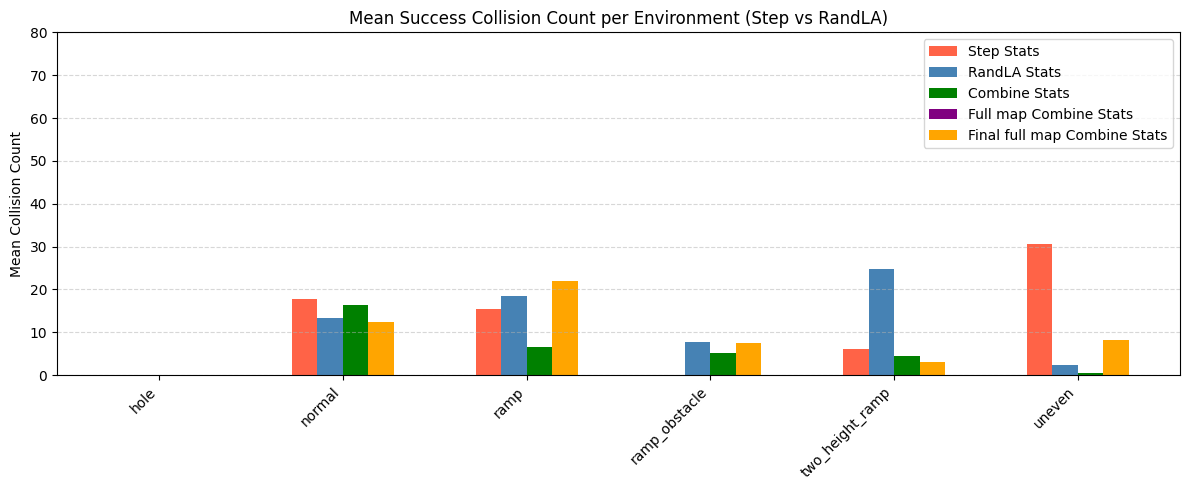

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Map from (rounded_start, rounded_goal) -> label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    """Convert {(start, goal): metrics} -> {label: metrics} using env_map.
       Falls back to 'start→goal' string if a pair isn't in env_map."""
    out = {}
    for (start, goal), vals in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        out[label] = vals
    return out

stats1_labeled = relabel_stats(stats1)  # step
stats2_labeled = relabel_stats(stats2)  # randla
stats3_labeled = relabel_stats(stats3)  # combine
stats4_labeled = relabel_stats(stats4)  # full map combine (or step6 in your earlier naming)
stats5_labeled = relabel_stats(stats5)

# Use ALL labels across the 4 series (not just step+randla)
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled)
)

# Build arrays
step_collision_means    = [stats1_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]  
randla_collision_means  = [stats2_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
combine_collision_means = [stats3_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
full_collision_means    = [stats4_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]
another_collision_means = [stats5_labeled.get(label, {}).get("mean_collision_success", 0) for label in all_labels]

# --- Looser spacing + centered offsets (like your success-rate plot) ---
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing

width = 0.25
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]  # Step, RandLA, Combine, Full

plt.figure(figsize=(max(12, len(all_labels)*0.7), 5))

bars1 = plt.bar(x + offsets[0], step_collision_means,    width, label='Step Stats',                color='tomato')
bars2 = plt.bar(x + offsets[1], randla_collision_means,  width, label='RandLA Stats',              color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_collision_means, width, label='Combine Stats',             color='green')
bars4 = plt.bar(x + offsets[3], full_collision_means,    width, label='Full map Combine Stats',    color='purple')
bars5 = plt.bar(x + offsets[3], full_collision_means,    width, label='Final full map Combine Stats',    color='orange')
plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Collision Count")
plt.title("Mean Success Collision Count per Environment (Step vs RandLA)")
plt.legend()

ylim_val = 80
plt.ylim(0, ylim_val)  # Fixed y-limit

plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

def label_only_over_limit(bars, limit=ylim_val, label_y=75):
    for bar in bars:
        height = bar.get_height()
        if height > limit:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{height:.1f}',
                ha='center',
                va='center',
                fontsize=5,
                fontweight='bold',
                color='black'
            )

label_only_over_limit(bars1)
label_only_over_limit(bars2)
label_only_over_limit(bars3)
label_only_over_limit(bars4)
label_only_over_limit(bars5)
plt.show()


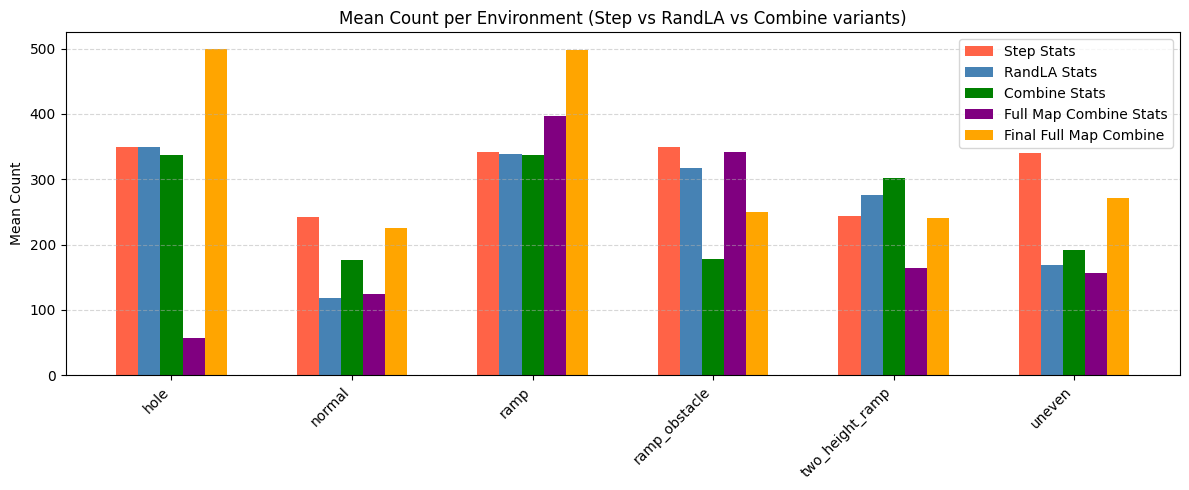

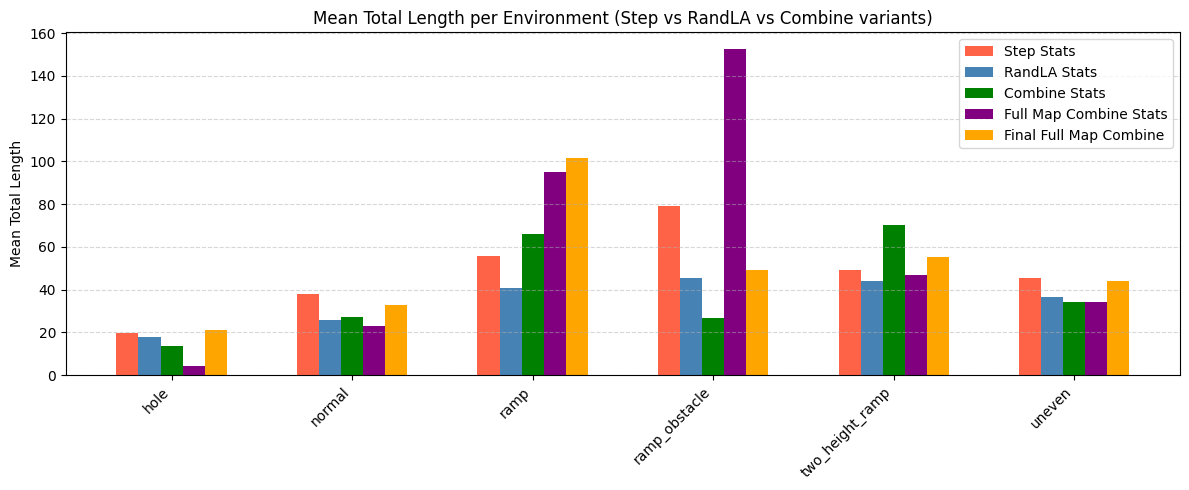

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Mapping from (rounded start, rounded goal) -> environment label
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    """Convert {(start, goal): metrics} -> {label: metrics} using env_map.
       Falls back to 'start→goal' string if pair not in env_map."""
    out = {}
    for (start, goal), vals in stats.items():
        label = env_map.get((start, goal), f"{start}→{goal}")
        out[label] = vals
    return out

# Apply relabeling
stats1_labeled = relabel_stats(stats1)  # step
stats2_labeled = relabel_stats(stats2)  # randla
stats3_labeled = relabel_stats(stats3)  # combine
stats4_labeled = relabel_stats(stats4)  # full map combine
stats5_labeled = relabel_stats(stats5)  # final full map combine

# Use ALL labels across the 5 series
all_labels = sorted(
    set(stats1_labeled) |
    set(stats2_labeled) |
    set(stats3_labeled) |
    set(stats4_labeled) |
    set(stats5_labeled)
)

# Data arrays
step_counts    = [stats1_labeled.get(label, {}).get("count", 0) for label in all_labels]
randla_counts  = [stats2_labeled.get(label, {}).get("count", 0) for label in all_labels]
combine_counts = [stats3_labeled.get(label, {}).get("count", 0) for label in all_labels]
full_counts    = [stats4_labeled.get(label, {}).get("count", 0) for label in all_labels]
final_counts   = [stats5_labeled.get(label, {}).get("count", 0) for label in all_labels]

step_lengths    = [stats1_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
randla_lengths  = [stats2_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
combine_lengths = [stats3_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
full_lengths    = [stats4_labeled.get(label, {}).get("total_length", 0) for label in all_labels]
final_lengths   = [stats5_labeled.get(label, {}).get("total_length", 0) for label in all_labels]

# --- Layout and spacing ---
group_spacing = 1.8
x = np.arange(len(all_labels)) * group_spacing
width = 0.22
offsets = [-2*width, -width, 0, width, 2*width]  # 5 bars centered around each group

def label_only_over_limit(bars, limit=None, label_y=None):
    """If bar height > limit, draw the numeric label at label_y."""
    if limit is None or label_y is None:
        return
    for bar in bars:
        h = bar.get_height()
        if h > limit:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                label_y,
                f'{h:.1f}',
                ha='center', va='center',
                fontsize=6, fontweight='bold', color='black'
            )

# -------------------------------
# Plot: Mean Count comparison
# -------------------------------
plt.figure(figsize=(max(12, len(all_labels)*0.7), 5))

bars1 = plt.bar(x + offsets[0], step_counts,    width, label='Step Stats',                color='tomato')
bars2 = plt.bar(x + offsets[1], randla_counts,  width, label='RandLA Stats',              color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_counts, width, label='Combine Stats',             color='green')
bars4 = plt.bar(x + offsets[3], full_counts,    width, label='Full Map Combine Stats',    color='purple')
bars5 = plt.bar(x + offsets[4], final_counts,   width, label='Final Full Map Combine',    color='orange')

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Count")
plt.title("Mean Count per Environment (Step vs RandLA vs Combine variants)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()

# Optional fixed y-limit
# ylim_val = 80
# plt.ylim(0, ylim_val)
# label_only_over_limit(bars1, limit=ylim_val, label_y=75)
# label_only_over_limit(bars2, limit=ylim_val, label_y=75)
# label_only_over_limit(bars3, limit=ylim_val, label_y=75)
# label_only_over_limit(bars4, limit=ylim_val, label_y=75)
# label_only_over_limit(bars5, limit=ylim_val, label_y=75)

plt.tight_layout()
plt.show()

# -------------------------------
# Plot: Mean Total Length comparison
# -------------------------------
plt.figure(figsize=(max(12, len(all_labels)*0.7), 5))

bars1 = plt.bar(x + offsets[0], step_lengths,    width, label='Step Stats',                color='tomato')
bars2 = plt.bar(x + offsets[1], randla_lengths,  width, label='RandLA Stats',              color='steelblue')
bars3 = plt.bar(x + offsets[2], combine_lengths, width, label='Combine Stats',             color='green')
bars4 = plt.bar(x + offsets[3], full_lengths,    width, label='Full Map Combine Stats',    color='purple')
bars5 = plt.bar(x + offsets[4], final_lengths,   width, label='Final Full Map Combine',    color='orange')

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.ylabel("Mean Total Length")
plt.title("Mean Total Length per Environment (Step vs RandLA vs Combine variants)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()

# Optional fixed y-limit
# ylim_val = 400
# plt.ylim(0, ylim_val)
# label_only_over_limit(bars1, limit=ylim_val, label_y=380)
# label_only_over_limit(bars2, limit=ylim_val, label_y=380)
# label_only_over_limit(bars3, limit=ylim_val, label_y=380)
# label_only_over_limit(bars4, limit=ylim_val, label_y=380)
# label_only_over_limit(bars5, limit=ylim_val, label_y=380)

plt.tight_layout()
plt.show()
